# Hjärtssjukdom – Prediktion med Machine Learning

Inläsning av dataset

In [11]:
import pandas as pd
data=pd.read_csv('../data/heart.csv')
data.head()

,Unnamed: 0,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  1025 non-null   int64  
 1   sex         1025 non-null   int64  
 2   cp          1025 non-null   int64  
 3   trestbps    1025 non-null   int64  
 4   chol        1025 non-null   int64  
 5   fbs         1025 non-null   int64  
 6   restecg     1025 non-null   int64  
 7   thalach     1025 non-null   int64  
 8   exang       1025 non-null   int64  
 9   oldpeak     1025 non-null   float64
 10  slope       1025 non-null   int64  
 11  ca          1025 non-null   int64  
 12  thal        1025 non-null   int64  
 13  target      1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


Utforska data

In [9]:
print(f"age avarge :{data['age'].mean()}")
print(f"cholostrol avarge:{data['chol'].mean()}")

KeyError: 'age'

En hög standardavvikelse innebär större spridning i datan och kan vara användbar, 
om variationen hjälper till att skilja mellan sjuka och friska.

In [ ]:


data.std()

age          9.072290
sex          0.460373
cp           1.029641
trestbps    17.516718
chol        51.592510
fbs          0.356527
restecg      0.527878
thalach     23.005724
exang        0.472772
oldpeak      1.175053
slope        0.617755
ca           1.030798
thal         0.620660
target       0.500070
dtype: float64

<Axes: >

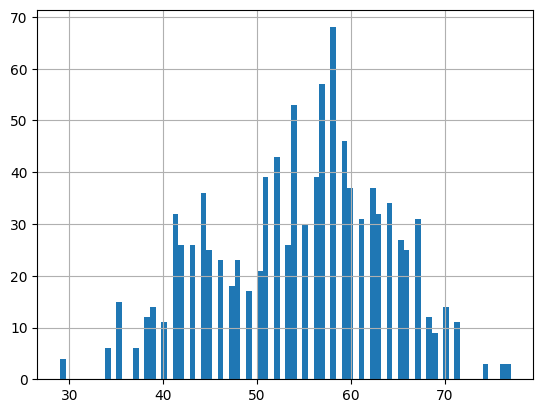

In [ ]:

#Histogrammet visar att de flesta individer i datasetet är mellan 50 och 60 år..
data["age"].hist(bins=80)

<Axes: >

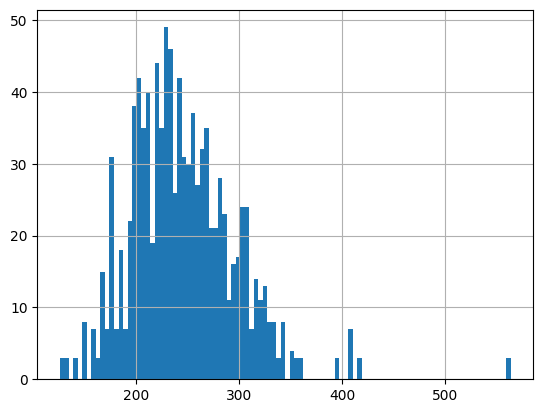

In [ ]:
data["chol"].hist(bins=100)

In [ ]:
data.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.103240,-0.071966,0.271121,0.219823,0.121243,-0.132696,-0.390227,0.088163,0.208137,-0.169105,0.271551,0.072297,-0.229324
sex,-0.103240,1.000000,-0.041119,-0.078974,-0.198258,0.027200,-0.055117,-0.049365,0.139157,0.084687,-0.026666,0.111729,0.198424,-0.279501
cp,-0.071966,-0.041119,1.000000,0.038177,-0.081641,0.079294,0.043581,0.306839,-0.401513,-0.174733,0.131633,-0.176206,-0.163341,0.434854
trestbps,0.271121,-0.078974,0.038177,1.000000,0.127977,0.181767,-0.123794,-0.039264,0.061197,0.187434,-0.120445,0.104554,0.059276,-0.138772
chol,0.219823,-0.198258,-0.081641,0.127977,1.000000,0.026917,-0.147410,-0.021772,0.067382,0.064880,-0.014248,0.074259,0.100244,-0.099966
fbs,0.121243,0.027200,0.079294,0.181767,0.026917,1.000000,-0.104051,-0.008866,0.049261,0.010859,-0.061902,0.137156,-0.042177,-0.041164
restecg,-0.132696,-0.055117,0.043581,-0.123794,-0.147410,-0.104051,1.000000,0.048411,-0.065606,-0.050114,0.086086,-0.078072,-0.020504,0.134468
thalach,-0.390227,-0.049365,0.306839,-0.039264,-0.021772,-0.008866,0.048411,1.000000,-0.380281,-0.349796,0.395308,-0.207888,-0.098068,0.422895
exang,0.088163,0.139157,-0.401513,0.061197,0.067382,0.049261,-0.065606,-0.380281,1.000000,0.310844,-0.267335,0.107849,0.197201,-0.438029
oldpeak,0.208137,0.084687,-0.174733,0.187434,0.064880,0.010859,-0.050114,-0.349796,0.310844,1.000000,-0.575189,0.221816,0.202672,-0.438441


Fördelningen av viloplus visar att de flesta värden ligger inom det normala intervallet, men det finns även vissa avvikande värden (outliers). I boxploten kan man dessutom se skillnader mellan personer med och utan sjukdo


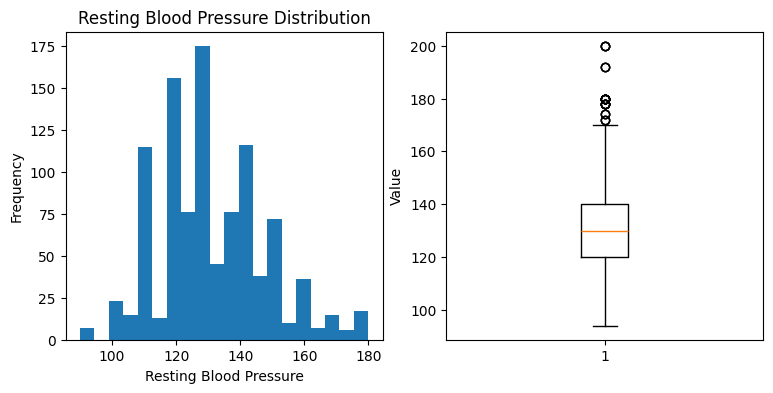

In [16]:

import matplotlib.pyplot as plt

fig, ax=plt.subplots(nrows=1, ncols=2, figsize=(9,4))
# det första diagrammet visar en histogram av vilopuls, vilket ger en visuell representation av fördelningen av vilopuls i datan.
n, bins, patches = ax[0].hist(data["trestbps"], bins=20, range=   (90,180))
ax[0].set(xlabel="Resting Blood Pressure", ylabel="Frequency", title="Resting Blood Pressure Distribution")

# det andra diagrammet visar en boxplot av vilopuls, vilket ger en visuell representation av fördelningen och eventuella outliers i datan.
ax[1].boxplot(data["trestbps"], label="Resting Blood Pressure")
ax[1].set (ylabel="Value")

plt.show()

fig.savefig("Diagram.png")